In [1]:
pip install astroquery

Note: you may need to restart the kernel to use updated packages.


In [2]:
from astroquery.vizier import Vizier
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.patches as patches
from matplotlib.text import Text
from mpl_toolkits.axes_grid1 import make_axes_locatable as mal

In [3]:
gaia_dr2 = Vizier(columns=['Teff', 'BP-RP','BP-G', 'Gmag', 'G-RP', 'Lum', 'Plx', 'e_Plx'], row_limit=20000).get_catalogs('I/345')[0].to_pandas()                        # importando catalgos gaia_dr2 e mstracks
mstracks2 = Vizier(columns=['Mass', 'Z', 'Y', 'logTeff', 'logL', 'Overshoot'], row_limit=20000).get_catalogs('J/A+AS/141/371')[0].to_pandas()


In [4]:
mstracks2 = mstracks2[(mstracks2['Overshoot'] == 1.00)]

A ideia é importar o crossmath entre esses dois catálogos, que pegará as estrelas em comum observada por dois satélites diferentes:

In [5]:
mstracks = pd.DataFrame()
gaia = gaia_dr2.copy()                                                           # fazendo copias dos catalogos originais
mstracks = mstracks2.copy()

In [6]:
mstracks

,Mass,Z,Y,logTeff,logL,Overshoot
0,0.15,0.0004,0.23,3.591,-2.304,1
1,0.15,0.0004,0.23,3.596,-2.260,1
2,0.20,0.0004,0.23,3.616,-2.008,1
3,0.20,0.0004,0.23,3.619,-1.945,1
4,0.25,0.0004,0.23,3.628,-1.796,1
...,...,...,...,...,...,...
13718,7.00,0.0300,0.30,3.561,4.116,1
13719,7.00,0.0300,0.30,3.555,4.171,1
13720,7.00,0.0300,0.30,3.549,4.226,1
13721,7.00,0.0300,0.30,3.546,4.285,1


In [7]:
for index, row in mstracks.iterrows():
    mstracks.loc[index, 'Teff'] = 10**(row['logTeff'])

for index, row in mstracks.iterrows():                                            # indice de cor por equacao do segundo grau para BV
    a = 4600/row['Teff']
    mstracks.loc[index, 'B-V'] = -1.87 + (1.61*a) + np.sqrt(0.78+(2.6*a*a))

In [8]:
for index, row in gaia.iterrows():
    gaia.loc[index, 'Plx/e_Plx'] = row['Plx']/row['e_Plx']

In [9]:
gaia.dropna(subset='Plx/e_Plx', inplace=True)
gaia = gaia[((gaia['Plx']/gaia['e_Plx']) > 5)]
gaia

,Teff,BP-RP,BP-G,Gmag,G-RP,Lum,Plx,e_Plx,Plx/e_Plx
1,NaN,2.5817,1.4091,17.6330,1.1726,NaN,3.3237,0.1433,23.193999
3,3968.25,2.0310,1.0298,15.9271,1.0012,0.058,3.0466,0.0589,51.724959
4,NaN,2.5585,1.3581,18.2828,1.2004,NaN,2.4526,0.2132,11.503752
6,5230.15,1.0461,0.4407,15.6254,0.6054,3.434,0.3591,0.0483,7.434782
11,NaN,2.6568,1.4032,19.0959,1.2536,NaN,3.2968,0.3569,9.237321
...,...,...,...,...,...,...,...,...,...
19991,NaN,2.4127,1.2708,18.7022,1.1419,NaN,1.9627,0.2452,8.004486
19995,NaN,2.6715,1.4213,18.3405,1.2502,NaN,1.6790,0.2263,7.419355
19996,NaN,1.9149,0.9260,17.3447,0.9889,NaN,1.6335,0.1467,11.134970
19998,NaN,2.1323,1.0807,18.2236,1.0517,NaN,1.7035,0.2152,7.915892


In [10]:
gaia.dropna(subset='BP-RP', inplace=True)                                         # drop de nan's
gaia.dropna(subset='Lum', inplace=True)
mstracks2

,Mass,Z,Y,logTeff,logL,Overshoot
0,0.15,0.0004,0.23,3.591,-2.304,1
1,0.15,0.0004,0.23,3.596,-2.260,1
2,0.20,0.0004,0.23,3.616,-2.008,1
3,0.20,0.0004,0.23,3.619,-1.945,1
4,0.25,0.0004,0.23,3.628,-1.796,1
...,...,...,...,...,...,...
13718,7.00,0.0300,0.30,3.561,4.116,1
13719,7.00,0.0300,0.30,3.555,4.171,1
13720,7.00,0.0300,0.30,3.549,4.226,1
13721,7.00,0.0300,0.30,3.546,4.285,1


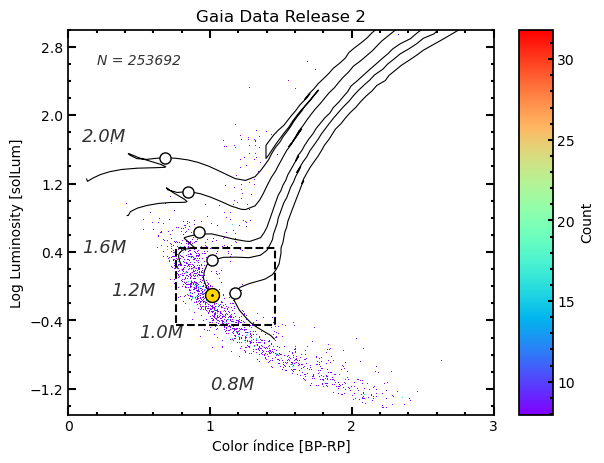

In [11]:
fig, ax = plt.subplots(figsize=(6.25, 5))
                                                                                            # ticks
ax.tick_params(which='major', direction='in', length=6, top=True, right=True, width=1.5)
ax.tick_params(which='minor', direction='in', length=2, top=True, right=True, width=1.5)
ax.minorticks_on()
plt.xticks(np.arange(-10, 11, 1))
plt.yticks(np.arange(-10, 11, 0.8))

x = gaia['BP-RP']
y = np.log10(gaia['Lum'])
                                                                                            # histograma 2d, curvas e pontos
h = ax.hist2d(x, y, bins = (500,500), density = True,cmap = 'rainbow', cmin=0.0001, alpha=1)

ax.plot(mstracks[(mstracks['Mass'] == 0.80) & (mstracks['Z'] == 0.019)]['B-V'], mstracks[(mstracks['Mass'] == 0.80) & (mstracks['Z'] == 0.019)]['logL'], c='k', linewidth=0.8)     # curvas de evolucao
ax.plot(mstracks[(mstracks['Mass'] == 1.00) & (mstracks['Z'] == 0.019)]['B-V'], mstracks[(mstracks['Mass'] == 1.00) & (mstracks['Z'] == 0.019)]['logL'], c='k', linewidth=0.8)
ax.plot(mstracks[(mstracks['Mass'] == 1.20) & (mstracks['Z'] == 0.019)]['B-V'], mstracks[(mstracks['Mass'] == 1.20) & (mstracks['Z'] == 0.019)]['logL'], c='k', linewidth=0.8)
ax.plot(mstracks[(mstracks['Mass'] == 1.60) & (mstracks['Z'] == 0.019)]['B-V'], mstracks[(mstracks['Mass'] == 1.60) & (mstracks['Z'] == 0.019)]['logL'], c='k', linewidth=0.8)
ax.plot(mstracks[(mstracks['Mass'] == 2.00) & (mstracks['Z'] == 0.019)]['B-V'], mstracks[(mstracks['Mass'] == 2.00) & (mstracks['Z'] == 0.019)]['logL'], c='k', linewidth=0.8)

ax.plot(1.1779, -0.077, marker='o', markerfacecolor='white', markeredgecolor='black', markeredgewidth=1, markersize=8)         # stars_points
ax.plot(1.01776, 0.305, marker='o', markerfacecolor='white', markeredgecolor='black', markeredgewidth=1, markersize=8)
ax.plot(0.920, 0.629, marker='o', markerfacecolor='white', markeredgecolor='black', markeredgewidth=1, markersize=8)
ax.plot(0.8486, 1.107, marker='o', markerfacecolor='white', markeredgecolor='black', markeredgewidth=1, markersize=8)
ax.plot(0.6839, 1.501, marker='o', markerfacecolor='white', markeredgecolor='black', markeredgewidth=1, markersize=8)

ax.plot(1.01226, -0.104, marker='o', markerfacecolor='gold', markeredgecolor='black', markeredgewidth=1, markersize=10)
ax.plot(1.01226, -0.104, marker='o', markerfacecolor='k', markeredgecolor='black', markeredgewidth=1, markersize=1)

ax.text(1.0, -1.2, '0.8M', fontsize=13, color='k', alpha=0.8, fontstyle='italic')                                                                             # text stars_points
ax.text(0.5, -0.6, '1.0M', fontsize=13, color='k', alpha=0.8, fontstyle='italic')
ax.text(0.3, -0.1, '1.2M', fontsize=13, color='k', alpha=0.8, fontstyle='italic')
ax.text(0.1, 0.4, '1.6M', fontsize=13, color='k', alpha=0.8, fontstyle='italic')
ax.text(0.1, 1.7, '2.0M', fontsize=13, color='k', alpha=0.8, fontstyle='italic')

ax.text(0.2, 2.6, 'N = 253692', fontsize=10, color='k', alpha=0.8, fontstyle='italic')

                                                                # rectangle

rect = patches.Rectangle((1.01226-0.25, -0.104-0.35), .7, .9, linewidth=1.5, edgecolor='k', facecolor='none', linestyle='dashed')
ax.add_patch(rect)

# Ajuste os limites do eixo para que o retângulo seja visível
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)

                                                                # details
ax.spines['top'].set_linewidth(1.25)
ax.spines['bottom'].set_linewidth(1.25)
ax.spines['left'].set_linewidth(1.25)
ax.spines['right'].set_linewidth(1.25)

plt.title('Gaia Data Release 2')
plt.xlabel('Color índice [BP-RP]')
plt.ylabel('Log Luminosity [solLum]')

#ax.set_xlim(0.5, 1.75)
#ax.set_ylim(-1, 1)
ax.set_xlim(0, 3)
ax.set_ylim(-1.5, 3)

                                                                # Ajuste do colorbar
divider = mal(plt.gca())
cax = divider.append_axes('right', size='8%', pad=0.25)
cbar = fig.colorbar(h[3], cax=cax, label='Count')

cbar.minorticks_on()
cbar.ax.tick_params(which='minor', direction='in')
cbar.ax.tick_params(which='major', direction='in')

cbar.outline.set_linewidth(1.25)
cbar.ax.tick_params(which='minor', width=1.5)
cbar.ax.tick_params(which='major', width=1.5)

plt.show()

In [12]:
cat = Vizier(columns=['Gmag'], row_limit=10000).get_catalogs('I/345')[0].to_pandas()

In [13]:
gaia2 = gaia.copy()

for index, row in cat.iterrows():
  gaia2.loc[index, 'Gmag'] = row['Gmag']

for index, row in gaia.iterrows():
  gaia2.loc[index, 'M'] = row['Gmag'] + 5*(np.log10(row['Plx']) + 1)

gaia2

,Teff,BP-RP,BP-G,Gmag,G-RP,Lum,Plx,e_Plx,Plx/e_Plx,M
3,3968.25,2.0310,1.0298,18.7177,1.0012,0.058,3.0466,0.0589,51.724959,23.346177
6,5230.15,1.0461,0.4407,20.9397,0.6054,3.434,0.3591,0.0483,7.434782,18.401477
14,5263.40,0.9118,0.3521,20.4882,0.5597,1.094,0.7423,0.0421,17.631829,19.637897
47,5071.26,1.0905,0.4724,20.4830,0.6182,0.588,1.5226,0.0312,48.801283,20.348429
51,5406.00,0.9505,0.3944,17.8739,0.5561,0.452,0.8508,0.0540,15.755555,20.576637
...,...,...,...,...,...,...,...,...,...,...
9994,NaN,NaN,NaN,18.8001,NaN,NaN,NaN,NaN,NaN,NaN
9995,NaN,NaN,NaN,19.6806,NaN,NaN,NaN,NaN,NaN,NaN
9997,NaN,NaN,NaN,21.0635,NaN,NaN,NaN,NaN,NaN,NaN
9998,NaN,NaN,NaN,20.0092,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
gaia3 = pd.DataFrame()
gaia3 = gaia2.copy()
gaia3

,Teff,BP-RP,BP-G,Gmag,G-RP,Lum,Plx,e_Plx,Plx/e_Plx,M
3,3968.25,2.0310,1.0298,18.7177,1.0012,0.058,3.0466,0.0589,51.724959,23.346177
6,5230.15,1.0461,0.4407,20.9397,0.6054,3.434,0.3591,0.0483,7.434782,18.401477
14,5263.40,0.9118,0.3521,20.4882,0.5597,1.094,0.7423,0.0421,17.631829,19.637897
47,5071.26,1.0905,0.4724,20.4830,0.6182,0.588,1.5226,0.0312,48.801283,20.348429
51,5406.00,0.9505,0.3944,17.8739,0.5561,0.452,0.8508,0.0540,15.755555,20.576637
...,...,...,...,...,...,...,...,...,...,...
9994,NaN,NaN,NaN,18.8001,NaN,NaN,NaN,NaN,NaN,NaN
9995,NaN,NaN,NaN,19.6806,NaN,NaN,NaN,NaN,NaN,NaN
9997,NaN,NaN,NaN,21.0635,NaN,NaN,NaN,NaN,NaN,NaN
9998,NaN,NaN,NaN,20.0092,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
gaia3 = gaia3[(np.abs(gaia3['M']-4.67) > 15.35)]

gaia3 = gaia3[((gaia3['Plx']/gaia3['e_Plx']) > 5)]
gaia3 = gaia3[(np.abs(gaia3['Teff']-5772) <= 150)]
gaia3 = gaia3[(np.abs(gaia3['BP-RP']-0.82) <= 0.05)]
gaia3 = gaia3[(np.abs(gaia3['BP-G']-0.33) <= 0.03)]
gaia3 = gaia3[(np.abs(gaia3['G-RP']-0.49) <= 0.02)]

gaia3.index =range(gaia3.shape[0])

gaia3.shape

(5, 10)

In [16]:
gaia2.dropna(subset='BP-RP', inplace=True)                                         # drop de nan's
gaia2.dropna(subset='Lum', inplace=True)

gaia3.dropna(subset='BP-RP', inplace=True)                                         # drop de nan's
gaia3.dropna(subset='Lum', inplace=True)
gaia3

,Teff,BP-RP,BP-G,Gmag,G-RP,Lum,Plx,e_Plx,Plx/e_Plx,M
0,5733.00,0.8266,0.3258,19.5246,0.5008,0.629,1.5696,0.0634,24.757098,20.186845
1,5758.00,0.8545,0.3481,18.1314,0.5064,0.725,0.6406,0.0646,9.916409,20.030435
2,5738.00,0.8683,0.3589,12.4579,0.5094,0.686,3.3622,0.1159,29.009490,20.091018
3,5836.50,0.8157,0.3167,12.7254,0.4989,0.599,3.1714,0.3095,10.246849,20.231655
4,5835.67,0.8153,0.3171,16.2882,0.4981,0.665,0.5835,0.0822,7.098540,20.118404


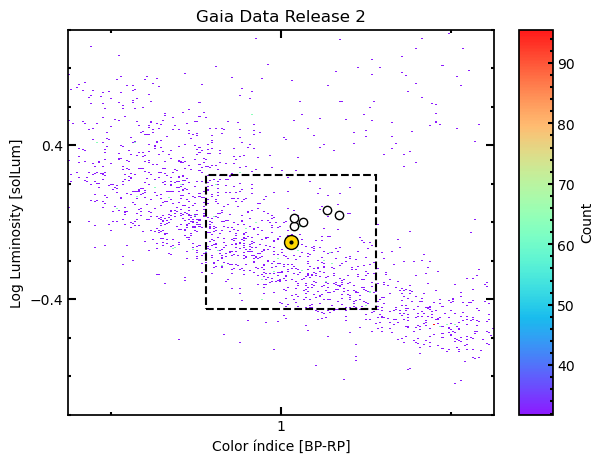

In [17]:
fig, ax = plt.subplots(figsize=(6.25, 5))
                                                                                            # ticks
ax.tick_params(which='major', direction='in', length=6, top=True, right=True, width=1.5)
ax.tick_params(which='minor', direction='in', length=2, top=True, right=True, width=1.5)
ax.minorticks_on()
plt.xticks(np.arange(-10, 11, 1))
plt.yticks(np.arange(-10, 11, 0.8))

x = gaia2['BP-RP']
y = np.log10(gaia2['Lum'])
x1 = gaia3['BP-RP']
y1 = np.log10(gaia3['Lum'])
                                                                                            # histograma 2d, curvas e pontos
h = ax.hist2d(x, y, bins = (1000,1000), density = True,cmap = 'rainbow', cmin=0.0001, alpha=0.9)
plt.scatter(x1+0.2, y1+0.2, color = '1.0', edgecolor = '0.0', alpha=1)
'''
ax.plot(mstracks[(mstracks['Mass'] == 0.80) & (mstracks['Z'] == 0.019)]['B-V'], mstracks[(mstracks['Mass'] == 0.80) & (mstracks['Z'] == 0.019)]['logL'], c='k', linewidth=0.8)     # curvas de evolucao
ax.plot(mstracks[(mstracks['Mass'] == 1.00) & (mstracks['Z'] == 0.019)]['B-V'], mstracks[(mstracks['Mass'] == 1.00) & (mstracks['Z'] == 0.019)]['logL'], c='k', linewidth=0.8)
ax.plot(mstracks[(mstracks['Mass'] == 1.20) & (mstracks['Z'] == 0.019)]['B-V'], mstracks[(mstracks['Mass'] == 1.20) & (mstracks['Z'] == 0.019)]['logL'], c='k', linewidth=0.8)
ax.plot(mstracks[(mstracks['Mass'] == 1.60) & (mstracks['Z'] == 0.019)]['B-V'], mstracks[(mstracks['Mass'] == 1.60) & (mstracks['Z'] == 0.019)]['logL'], c='k', linewidth=0.8)
ax.plot(mstracks[(mstracks['Mass'] == 2.00) & (mstracks['Z'] == 0.019)]['B-V'], mstracks[(mstracks['Mass'] == 2.00) & (mstracks['Z'] == 0.019)]['logL'], c='k', linewidth=0.8)'''
'''
ax.plot(1.1779, -0.077, marker='o', markerfacecolor='white', markeredgecolor='black', markeredgewidth=1, markersize=8)         # stars_points
ax.plot(1.01776, 0.305, marker='o', markerfacecolor='white', markeredgecolor='black', markeredgewidth=1, markersize=8)
ax.plot(0.920, 0.629, marker='o', markerfacecolor='white', markeredgecolor='black', markeredgewidth=1, markersize=8)
ax.plot(0.8486, 1.107, marker='o', markerfacecolor='white', markeredgecolor='black', markeredgewidth=1, markersize=8)
ax.plot(0.6839, 1.501, marker='o', markerfacecolor='white', markeredgecolor='black', markeredgewidth=1, markersize=8)
'''
ax.plot(1.01226, -0.104, marker='o', markerfacecolor='gold', markeredgecolor='black', markeredgewidth=1, markersize=10)
ax.plot(1.01226, -0.104, marker='o', markerfacecolor='k', markeredgecolor='black', markeredgewidth=1, markersize=2)
'''
ax.text(1.0, -1.2, '0.8M', fontsize=13, color='k', alpha=0.8, fontstyle='italic')                                                                             # text stars_points
ax.text(0.5, -0.6, '1.0M', fontsize=13, color='k', alpha=0.8, fontstyle='italic')
ax.text(0.3, -0.1, '1.2M', fontsize=13, color='k', alpha=0.8, fontstyle='italic')
ax.text(0.1, 0.4, '1.6M', fontsize=13, color='k', alpha=0.8, fontstyle='italic')
ax.text(0.1, 1.7, '2.0M', fontsize=13, color='k', alpha=0.8, fontstyle='italic')
'''

                                                                # rectangle

rect = patches.Rectangle((1.01226-0.1, -0.104-0.35), .2, .7, linewidth=1.5, edgecolor='k', facecolor='none', linestyle='dashed')
ax.add_patch(rect)

# Ajuste os limites do eixo para que o retângulo seja visível
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)

                                                                # details
ax.spines['top'].set_linewidth(1.25)
ax.spines['bottom'].set_linewidth(1.25)
ax.spines['left'].set_linewidth(1.25)
ax.spines['right'].set_linewidth(1.25)

plt.title('Gaia Data Release 2')
plt.xlabel('Color índice [BP-RP]')
plt.ylabel('Log Luminosity [solLum]')

ax.set_xlim(0.75, 1.25)
ax.set_ylim(-1, 1)

#ax.set_xlim(0, 3)
#ax.set_ylim(-1.5, 3)

                                                                # Ajuste do colorbar
divider = mal(plt.gca())
cax = divider.append_axes('right', size='8%', pad=0.25)
cbar = fig.colorbar(h[3], cax=cax, label='Count')

cbar.minorticks_on()
cbar.ax.tick_params(which='minor', direction='in')
cbar.ax.tick_params(which='major', direction='in')

cbar.outline.set_linewidth(1.25)
cbar.ax.tick_params(which='minor', width=1.5)
cbar.ax.tick_params(which='major', width=1.5)

plt.show()